# Importações

In [1]:
# Importando bibliotecas, módulos e recursos
import optuna
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from optuna import create_study, Trial
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate

Neste notebook, o objetivo é explorar um conjunto de dados de formação de vidro inicialmente obtido pelo módulo SciGlass Python, já pré-processado e fazer as alterações apropriadas para o uso de métodos de aprendizado de máquina. Este conjunto de dados contém inicialmente mais de 72 mil exemplos de composições e 318 atributos associados aos materiais de composição. Existem 317 atributos quantitativos de compostos inorgânicos que podem estar presentes no material e 1 atributo qualitativo que rotula os compostos que formam vidro, cristais ou intermediários (GF).

No DataFrame abaixo, foram filtrados apenas os 3 rótulos com maior abordagem do dados, ou seja, os rótulos "Glass", "Crystal" e "Clear Glass" que representam 50.460 das composições totais. Esse filtro foi necessário para diminuir o "viés" dos dados, ou deixá-los mais fidedignos possível removendo rótulos que não condiziam com a classificação correta do material e que não trouxesse um grande prejuízo para o DataFrame.

# Classificação Binária

Para iniciar a modelagem dos dados e alguns testes de classificação, precisamos tornar os dados binários. Assim, os rótulos "Glass" e "Clear Glass" foram classificados como 1, pois são vidros. Já o rótulo "Crystal" foi classificado como 0, pois não é um vidro.

In [2]:
df = pd.read_csv("../data/processed/GFdata_compound_binary.csv", sep="\t")
df

,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,...,P2Se5,BiNbO4,Se4I,GeTe4.3,GaTe3,ZnI2,Na2Se,MgS,AsTe3,GF
0,0.0,0.0,0.00,0.0,0.00,0.00,76.84,4.6,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
1,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
2,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,34.650000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
3,0.0,0.0,16.16,0.0,0.00,83.76,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
4,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50455,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,57.148686,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
50456,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
50457,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass
50458,0.0,0.0,0.00,0.0,0.00,89.89,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Glass


In [3]:
df = pd.read_csv("../data/processed/atributos_engenheirados.csv", sep=",")
df

,Ag,Al,As,B,Ba,Be,Bi,Br,Ca,Cd,...,A|NsValence|mean,A|NsValence|min,A|NsValence|max,A|NsValence|std,A|SpaceGroupNumber|sum,A|SpaceGroupNumber|mean,A|SpaceGroupNumber|min,A|SpaceGroupNumber|max,A|SpaceGroupNumber|std,GF
0,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,437.0,109.250000,2.0,229.0,103.056720,Glass
1,0.0,0.019778,0.0,0.000000,0.095638,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,708.0,118.000000,2.0,229.0,108.412791,Glass
2,0.0,0.071696,0.0,0.195305,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,643.0,128.600000,12.0,225.0,96.421160,Glass
3,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,1.50,1.0,2.0,0.500000,622.0,155.500000,12.0,229.0,88.612922,Glass
4,0.0,0.287648,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,464.0,154.666667,12.0,227.0,100.883872,Glass
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50455,0.0,0.000000,0.0,0.291555,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,467.0,116.750000,12.0,225.0,83.514595,Glass
50456,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,1.75,1.0,2.0,0.433013,697.0,174.250000,12.0,229.0,93.678640,Glass
50457,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,2.00,2.0,2.0,0.000000,431.0,143.666667,12.0,225.0,93.958620,Glass
50458,0.0,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,1.75,1.0,2.0,0.433013,534.0,133.500000,12.0,229.0,77.911809,Glass


In [5]:
features_columns = []
for column in df.columns:
    features_columns.append(column)
features_columns.remove('GF')

FEATURES = features_columns
TARGET = ['GF']

df = df.reindex(FEATURES + TARGET, axis=1)

binarizador = LabelBinarizer()
binarizador.fit(df[TARGET])

nomes_das_features = binarizador.classes_

print(binarizador.transform(df[TARGET]))

df[TARGET] = binarizador.transform(df[TARGET])

[[1]
 [1]
 [1]
 ...
 [1]
 [1]
 [1]]


In [6]:
# Exibindo o DataFrame com a nova coluna de classificação
display(df)

,ZnO,Sb2O3,Na2O,MoO3,Bi2O3,TeO2,V2O5,P2O5,B2O3,CaO,...,P2Se5,BiNbO4,Se4I,GeTe4.3,GaTe3,ZnI2,Na2Se,MgS,AsTe3,GF
0,0.0,0.0,0.00,0.0,0.00,0.00,76.84,4.6,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
1,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,34.650000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
3,0.0,0.0,16.16,0.0,0.00,83.76,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
50455,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,57.148686,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
50456,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
50457,0.0,0.0,0.00,0.0,0.00,0.00,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
50458,0.0,0.0,0.00,0.0,0.00,89.89,0.00,0.0,0.000000,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


# Modelos de Classificação

Com o DataFrame já tratado, inicaremos os teste com alguns modelos de classificação. Na caixa abaixo, separamos as variáveis entre Features e Target.

In [7]:
# Define a proporção do conjunto de teste em relação ao conjunto total (70% treino, 30% teste)
TAMANHO_TESTE = 0.1

# Define a semente aleatória para garantir reprodutibilidade dos resultados
SEMENTE_ALEATORIA = 0

indices = df.index

# Divide os índices em conjuntos de treino e teste usando a função train_test_split do scikit-learn
indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA
)

# Obtém os conjuntos de treino e teste usando os índices obtidos
df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

# Obtém os valores das features e do target para o conjunto de treino
X_treino = df_treino.reindex(FEATURES, axis=1).values
y_treino = df_treino.reindex(TARGET, axis=1).values.ravel()

# Obtém os valores das features e do target para o conjunto de teste
X_teste = df_teste.reindex(FEATURES, axis=1).values
y_teste = df_teste.reindex(TARGET, axis=1).values.ravel()


## Baseline

O modelo baseline mais simples de classificação é o modelo que sempre prevê o dado mais frequente que observou durante o treino.

In [8]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()

modelo_baseline.fit(X_treino, y_treino)

DummyClassifier()

Matriz de Confusão:
[[   0 1505]
 [   0 3541]]


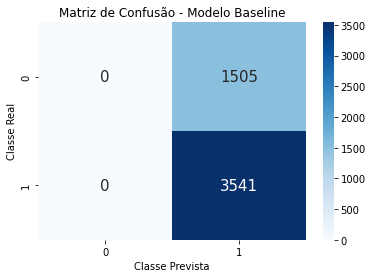

In [9]:
from sklearn.metrics import confusion_matrix

# Fazendo previsões com o modelo baseline nos dados de teste
y_pred_baseline = modelo_baseline.predict(X_teste)

# Calculando a matriz de confusão
matriz_confusao_baseline = confusion_matrix(y_teste, y_pred_baseline)

print("Matriz de Confusão:")
print(matriz_confusao_baseline)

# Plotando a matriz de confusão como um heatmap
sns.heatmap(matriz_confusao_baseline, annot=True, annot_kws={"size": 15}, fmt='d', cmap='Blues')

plt.xlabel('Classe Prevista')
plt.ylabel('Classe Real')
plt.title('Matriz de Confusão - Modelo Baseline')
plt.show()

Visualizando métricas.

In [10]:
from sklearn.metrics import classification_report

print("Relatório de Classificação:")
print(classification_report(y_teste, y_pred_baseline))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      1505
           1       0.70      1.00      0.82      3541

    accuracy                           0.70      5046
   macro avg       0.35      0.50      0.41      5046
weighted avg       0.49      0.70      0.58      5046



c:\venv\ilumpy\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\venv\ilumpy\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
c:\venv\ilumpy\lib\site-packages\sklearn\metrics\_classification.py:1248: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


O relatório de classificação fornece métricas de desempenho do modelo de classificação para cada classe, bem como métricas agregadas para avaliar o desempenho geral do modelo.

1. **Precision (Precisão)**: 
   - Precisão para a classe 0: 0.00 (0%)
   - Precisão para a classe 1: 0.71 (71%)
   - A precisão é a proporção de verdadeiros positivos (TP) em relação ao total de exemplos classificados como positivos (TP + falso positivo (FP)). 
   - No caso da classe 0, uma precisão de 0% indica que não houve verdadeiros positivos para essa classe, ou seja, nenhum exemplo da classe 0 foi corretamente classificado. Para a classe 1, a precisão indica que 71% dos exemplos classificados como pertencentes à classe 1 foram corretamente identificados.

2. **Recall (Revocação ou Sensibilidade)**:
   - Recall para a classe 0: 0.00 (0%)
   - Recall para a classe 1: 1.00 (100%)
   - O recall é a proporção de verdadeiros positivos (TP) em relação ao total de exemplos que realmente pertencem à classe (TP + falso negativo (FN)). 
   - Para a classe 0, o recall de 0% indica que nenhum exemplo da classe 0 foi corretamente identificado entre todos os exemplos dessa classe. Para a classe 1, o recall de 100% indica que todos os exemplos da classe 1 foram corretamente identificados.

3. **F1-score (F1-Score)**:
   - F1-score para a classe 0: 0.00 (0%)
   - F1-score para a classe 1: 0.83 (83%)
   - O F1-score é uma média harmônica da precisão e do recall, dando mais peso às classes com menos exemplos.
   - O F1-score é baixo para a classe 0 devido à baixa precisão e recall, enquanto é alto para a classe 1, indicando um bom equilíbrio entre precisão e recall.

4. **Acurácia (Accuracy)**:
   - Acurácia: 0.71 (71%)
   - A acurácia é a proporção de exemplos corretamente classificados (verdadeiros positivos e verdadeiros negativos) em relação ao total de exemplos.
   - A acurácia geral do modelo é de 71%, o que indica que 71% de todas as previsões estão corretas.

5. **Macro avg e Weighted avg**:
   - Essas são médias das métricas (precisão, recall, F1-score) calculadas para cada classe.
   - Macro avg calcula a média não ponderada das métricas para todas as classes, enquanto Weighted avg leva em consideração o suporte (número de exemplos verdadeiros para cada classe) ao calcular a média, dando mais peso às classes com mais exemplos.

## $k$-NN

KNN, ou K Nearest Neighbor usa da semelhança entre os dados para fazer classificações ou clusternizações. Com o KNN é possível ter um determinado conjunto de dados e a partir dele traçar padrões que podem classificar ou agrupar nossos dados.

O conceito de vizinhança depende da ideia de que aqueles que estão próximos as nós tendem a ser mais parecidos com nós. A partir dessa noção, o que o KNN faz é criar vizinhanças em nosso conjunto de dados e conforme formos passando outras amostras de dados para o modelo ele nos retornará em “qual vizinhança nossa amostra melhor se encaixaria”!

Fonte: https://luis-miguel-code.medium.com/knn-k-nearest-neighbor-e-kneighborsclassifier-o-que-%C3%A9-como-funciona-e-exemplo-pr%C3%A1tico-5fdf181f460c

O modelo de $k$​-NN para classificação é muito similar ao de regressão. A diferença está após os $k$ vizinhos serem identificados: neste momento, ao invés de retornar a média dos valores dos vizinhos, o modelo retorna a *moda* destes valores. Por conta disso, é recomendado utilizar um valor ímpar para $k$ em problemas de classificação binária.

Vamos treinar um classificador $k$​-NN e observar a matriz de confusão.

Matriz de Confusão:
[[ 841  664]
 [ 306 3235]]


<AxesSubplot:>

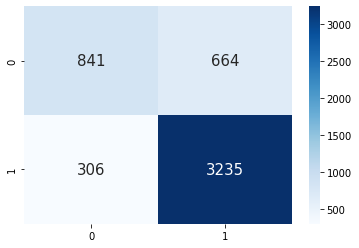

In [11]:
from sklearn.neighbors import KNeighborsClassifier

# Instancia um objeto da classe KNeighborsClassifier para criar um modelo de classificação KNN
modelo_knn = KNeighborsClassifier()

# Treina o modelo KNN utilizando os dados de treino
modelo_knn.fit(X_treino, y_treino)

# Define as variáveis para o verdadeiro alvo (y_verdadeiro) e para as previsões (y_previsao)
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(X_teste)

# Calcula a matriz de confusão com base nas previsões do modelo
matriz_confusao_knn = confusion_matrix(y_verdadeiro, y_previsao)

# Imprime a matriz de confusão
print("Matriz de Confusão:")
print(matriz_confusao_knn)

# Plota a matriz de confusão como um mapa de calor usando Seaborn
sns.heatmap(matriz_confusao_knn, annot=True, annot_kws={"size": 15}, fmt='d', cmap='Blues')

Visualizando Métricas.

In [12]:
print("Relatório de Classificação:")
print(classification_report(y_teste, y_previsao))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.73      0.56      0.63      1505
           1       0.83      0.91      0.87      3541

    accuracy                           0.81      5046
   macro avg       0.78      0.74      0.75      5046
weighted avg       0.80      0.81      0.80      5046



   Na matriz de confusão fornecida:
   - Para a classe 0 (primeira linha), temos 2273 verdadeiros negativos (TN) e 2108 falsos positivos (FP).
   - Para a classe 1 (segunda linha), temos 918 falsos negativos (FN) e 9839 verdadeiros positivos (TP).

Relatório de Classificação:

   1. **Precision (Precisão)**:
       - Para a classe 0, a precisão é de 0.71, o que indica que 71% dos exemplos classificados como pertencentes à classe 0 foram corretamente identificados.
       - Para a classe 1, a precisão é de 0.82, o que indica que 82% dos exemplos classificados como pertencentes à classe 1 foram corretamente identificados.
     
   2. **Recall (Revocação)**:
       - Para a classe 0, o recall é de 0.52, o que indica que 52% dos exemplos da classe 0 foram corretamente identificados entre todos os exemplos dessa classe.
        - Para a classe 1, o recall é de 0.91, o que indica que 91% dos exemplos da classe 1 foram corretamente identificados entre todos os exemplos dessa classe.
     
   3. **F1-score (F1-Score)**:
        - O F1-score é uma média harmônica da precisão e do recall, fornecendo uma medida balanceada entre eles.
        - Para a classe 0, o F1-score é de 0.60, enquanto para a classe 1 é de 0.87.
     
   4. **Acurácia (Accuracy)**:
        - A acurácia geral do modelo é de 0.80, indicando que 80% das previsões estão corretas.
     
   5. **Macro avg e Weighted avg**:
        - As médias das métricas calculadas para cada classe, sendo a macro avg a média não ponderada e a weighted avg considerando o suporte de cada classe.
        - No caso, ambas as médias apresentam valores consistentes com as métricas individuais para cada classe.

## Floresta Aleatória

Um algoritmo de machine learning que combina a saída de várias árvores de decisão para alcançar um único resultado. Sua facilidade de uso e flexibilidade incentivaram a sua adoção, pois lida tanto com problemas de classificação quanto de regressão.

As árvores de decisão começam com uma pergunta básica, como "devo navegar?" A partir daí, é possível fazer uma série de perguntas para determinar uma resposta, como "você pode perguntar uma série de perguntas para determinar uma resposta, como "as ondas são de longo período?" ou "o vento está soprando em alto mar?". Essas perguntas formam os nós de decisão na árvore, agindo como um meio de dividir os dados. Cada pergunta ajuda um indivíduo a chegar a uma decisão final, que seria indicada pelo nó folha. Observações que se enquadram nos critérios seguirão a ramificação "Sim" e aquelas que não se enquadram seguirão um caminho alternativo.  As árvores de decisão buscam a melhor divisão para criar subconjuntos de dados e elas são geralmente treinadas por meio do algoritmo de árvore de classificação e regressão (CART). Métricas, como impureza de Gini, ganho de informação ou erro quadrático médio (MSE), podem ser utilizadas para avaliar a qualidade da divisão.

Fonte: https://www.ibm.com/br-pt/topics/random-forest#:~:text=o%20pr%C3%B3ximo%20passo-,O%20que%20%C3%A9%20floresta%20aleat%C3%B3ria%3F,para%20alcan%C3%A7ar%20um%20%C3%BAnico%20resultado.

Matriz de Confusão:
[[ 952  553]
 [ 262 3279]]


<AxesSubplot:>

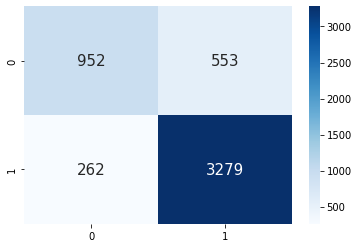

In [13]:
from sklearn.ensemble import RandomForestClassifier

# Instancia um objeto da classe RandomForestClassifier para criar um modelo de classificação com Random Forest
modelo_rf = RandomForestClassifier()

# Treina o modelo Random Forest utilizando os dados de treino
modelo_rf.fit(X_treino, y_treino)

y_verdadeiro = y_teste
y_previsao = modelo_rf.predict(X_teste)

matriz_confusao_rf = confusion_matrix(y_verdadeiro, y_previsao)
print("Matriz de Confusão:")
print(matriz_confusao_rf)

# Plota a matriz de confusão como um mapa de calor usando Seaborn
sns.heatmap(matriz_confusao_rf, annot=True, annot_kws={"size": 15}, fmt='d', cmap='Blues')

In [14]:
print("Relatório de Classificação:")
print(classification_report(y_teste, y_previsao))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.78      0.63      0.70      1505
           1       0.86      0.93      0.89      3541

    accuracy                           0.84      5046
   macro avg       0.82      0.78      0.79      5046
weighted avg       0.83      0.84      0.83      5046



1. **Precision (Precisão)**:
   - Para a classe 0 (não pertencente à classe), a precisão é de 0.76, o que significa que 76% dos exemplos classificados como não pertencentes à classe foram corretamente identificados.
   - Para a classe 1 (pertencente à classe), a precisão é de 0.84, indicando que 84% dos exemplos classificados como pertencentes à classe foram corretamente identificados.

2. **Recall (Revocação)**:
   - Para a classe 0, o recall é de 0.58, indicando que 58% dos exemplos verdadeiros da classe 0 foram corretamente identificados entre todos os exemplos dessa classe.
   - Para a classe 1, o recall é de 0.92, indicando que 92% dos exemplos verdadeiros da classe 1 foram corretamente identificados entre todos os exemplos dessa classe.

3. **F1-score (F1-Score)**:
   - O F1-score é uma média harmônica da precisão e do recall, fornecendo uma medida balanceada entre eles.
   - Para a classe 0, o F1-score é de 0.66, enquanto para a classe 1 é de 0.88.

4. **Acurácia (Accuracy)**:
   - A acurácia geral do modelo é de 0.82, indicando que 82% das previsões estão corretas.

5. **Macro avg e Weighted avg**:
   - As médias das métricas calculadas para cada classe, sendo a macro avg a média não ponderada e a weighted avg considerando o suporte de cada classe.
   - No caso, ambas as médias apresentam valores consistentes com as métricas individuais para cada classe.

Essas métricas indicam que o modelo de Floresta Aleatória teve um desempenho bastante bom na classificação das duas classes, com uma precisão geral de 82%. No entanto, é importante notar que a classe 0 (não pertencente à classe) tem um recall relativamente mais baixo em comparação com a classe 1 (pertencente à classe), o que pode indicar que o modelo tem mais dificuldade em identificar corretamente os exemplos da classe 0.

## Regressão Logística

A Regressão Logística é um método estatístico utilizado para prever a probabilidade de ocorrência de um evento binário, como "sim" ou "não", "passou" ou "não passou", com base em variáveis explicativas. Ao contrário da regressão linear, que prevê valores contínuos, a regressão logística é adequada para lidar com variáveis de resposta categóricas.

Para fazer previsões, a regressão logística parte do pressuposto de que há uma relação linear entre as variáveis explicativas e o logaritmo das chances do evento ocorrer. Utiliza-se uma função sigmoid para converter esses logaritmos em probabilidades, onde valores próximos de 0 indicam baixa probabilidade do evento e valores próximos de 1 indicam alta probabilidade.

Na regressão logística, a probabilidade de ocorrência de um evento pode ser estimada diretamente. No caso da variável dependente Y assumir apenas dois possíveis estados (1 ou 0) e haver um conjunto de p variáveis independentes X1 , X2 , ... , Xp, o modelo de regressão logística pode ser escrito da seguinte forma:

<img src="https://github.com/AnaLoponi/SudokuGA/assets/52572715/6ced4ea7-6ea1-4da0-a490-7738565b97b9">

Fonte: https://edisciplinas.usp.br/pluginfile.php/3769787/mod_resource/content/1/09_RegressaoLogistica.pdf

Por exemplo, ao prever se um estudante vai passar em um exame com base no tempo de estudo, a regressão logística utiliza uma equação que combina o tempo de estudo com coeficientes associados a essas variáveis. A função sigmoid é então aplicada para transformar esses resultados em probabilidades.

Essa abordagem permite interpretar a saída da regressão logística como probabilidades e classificar os resultados previstos com base em um limite predefinido. Assim, a regressão logística é uma ferramenta valiosa para prever e entender eventos binários com base em variáveis explicativas, sendo aplicável em diversas áreas como medicina, ciências sociais, marketing e finanças.

In [15]:
from sklearn.linear_model import LogisticRegression

# Instancia um objeto da classe LogisticRegression para criar um modelo de regressão logística
modelo_regressao_logistica = LogisticRegression()

modelo_regressao_logistica.fit(X_treino, y_treino)

# Faz previsões com base nos dados de teste
y_pred = modelo_regressao_logistica.predict(X_teste)

# Imprime o relatório de classificação, que inclui métricas de desempenho como precisão, recall, F1-score e acurácia
print("Relatório de Classificação:")
print(classification_report(y_teste, y_pred))

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.60      0.20      0.30      1505
           1       0.73      0.94      0.83      3541

    accuracy                           0.72      5046
   macro avg       0.67      0.57      0.56      5046
weighted avg       0.69      0.72      0.67      5046



c:\venv\ilumpy\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


1. **Precision (Precisão)**:
   - Para a classe 0, a precisão é de 0.59, o que significa que 59% dos exemplos classificados como não pertencentes à classe foram corretamente identificados.
   - Para a classe 1, a precisão é de 0.74, indicando que 74% dos exemplos classificados como pertencentes à classe foram corretamente identificados.

2. **Recall (Revocação)**:
   - Para a classe 0, o recall é de 0.18, indicando que apenas 18% dos exemplos verdadeiros da classe 0 foram corretamente identificados entre todos os exemplos dessa classe.
   - Para a classe 1, o recall é de 0.95, indicando que 95% dos exemplos verdadeiros da classe 1 foram corretamente identificados entre todos os exemplos dessa classe.

3. **F1-score (F1-Score)**:
   - O F1-score é uma média harmônica da precisão e do recall, fornecendo uma medida balanceada entre eles.
   - Para a classe 0, o F1-score é de 0.28, enquanto para a classe 1 é de 0.83.

4. **Acurácia (Accuracy)**:
   - A acurácia geral do modelo é de 0.73, indicando que 73% das previsões estão corretas.

5. **Macro avg e Weighted avg**:
   - As médias das métricas calculadas para cada classe, sendo a macro avg a média não ponderada e a weighted avg considerando o suporte de cada classe.
   - No caso, ambas as médias apresentam valores consistentes com as métricas individuais para cada classe.

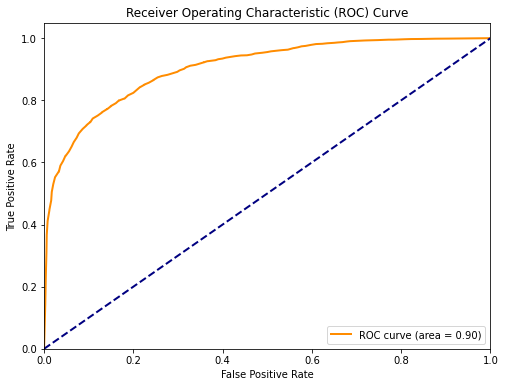

In [16]:
# Importa as funções roc_curve e auc do módulo sklearn.metrics
from sklearn.metrics import roc_curve, auc

# Calcula as probabilidades previstas para a classe positiva (classe 1) a partir do modelo de regressão logística
y_pred_proba = modelo_rf.predict_proba(X_teste)[:, 1]

# Calcula a Taxa de Falsos Positivos (FPR), a Taxa de Verdadeiros Positivos (TPR) e os limiares (thresholds) da curva ROC
fpr, tpr, thresholds = roc_curve(y_teste, y_pred_proba)

# Calcula a Área Sob a Curva ROC (ROC AUC)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)  # Curva ROC
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')  # Linha base (aleatória)
plt.xlim([0.0, 1.0])  # Limites do eixo x
plt.ylim([0.0, 1.05])  # Limites do eixo y
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

Este código calcula a curva ROC (Receiver Operating Characteristic) e a área sob a curva ROC (ROC AUC) para o modelo de regressão logística. A curva ROC é uma representação gráfica da taxa de verdadeiros positivos (TPR) versus a taxa de falsos positivos (FPR) em vários pontos de corte (limiares) para um classificador binário. A área sob a curva ROC (ROC AUC) é uma medida da capacidade do modelo de distinguir entre as duas classes.

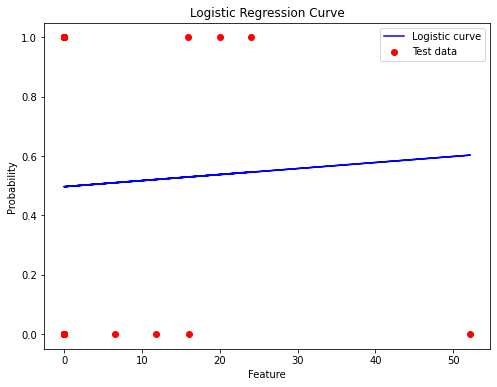

In [17]:
coef = modelo_regressao_logistica.coef_[0]
intercept = modelo_regressao_logistica.intercept_

# Definir a função logística
def logistic_function(x,coef,intercept):
    return 1 / (1 + np.exp(-(coef * x + intercept)))


coluna = 205 # equação logistica que representa a relação da coluna com o resultado 
# Plotar a curva logística
plt.figure(figsize=(8, 6))
#plt.scatter(X_treino[:,0], y_treino, color='black', label='Training data')
plt.scatter(X_teste[:,coluna], y_teste, color='red', label='Test data')
plt.plot(X_teste[:,coluna], logistic_function(X_teste[:,coluna], coef[coluna], intercept), color='blue', label='Logistic curve')
plt.xlabel('Feature')
plt.ylabel('Probability')
plt.title('Logistic Regression Curve')
plt.legend()
plt.show()

#print(coef)
#len(coef)
#print(logistic_function(10, coef, intercept))

Este código mostrará a curva de regressão logística para a característica específica selecionada, sobreposta aos pontos de dados de teste dessa característica. Isso permite visualizar como o modelo de regressão logística se ajusta aos dados.